# Uso de GridSearchCV en clasificación

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ja.meza@profesor.duoc.cl

**Fecha de Creación:** Mayo de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece la explicación del uso de GridSearchCV para el manejo de los hiperparámetros de los modelos de clasificación

Mantiene el uso de pipeline como buena práctica de la industria.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

# Conceptos contenidos en el ejemplo

## `Cross-Validation`

Dividir los datos en k folds:

+ entrenar con k-1 folds

+ validar con el fold restante

+ repetir k veces

Resultado:

+ k métricas

+ promedio más robusto

Qué logra

+ Reduce la varianza del resultado

+ Usa mejor los datos

+ Da una estimación más confiable del rendimiento real

## `GridSearchCV`

Probar combinaciones de hiperparámetros y evaluar cada combinación

```python
param_grid = {
   "max_depth": [3, 5, 10],
   "min_samples_split": [2, 5]
}
```
---
**`GridSearchCV` usa `cross-validation` internamente**

----

## `StratifiedKFold`

Mantiene la proporción de clases en cada fold

Evita casos como:
+ folds sin clase minoritaria ❌
+ métricas inestables ❌
+ Hace la evaluación más representativa y consistente ✔️

# Clases para la preparación de los datos

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [ ]:
def tratar_duplicados(X : pd.DataFrame, drop = True):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.
  drop : bool
    Si se deben eliminar los duplicados.

  Retorna
  -------
  DataFrame
    Conjunto de datos sin duplicados.
  """
  return X.drop_duplicates() if drop else X

In [ ]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

In [ ]:
def evaluar(modelo: BaseEstimator, X_train: np.array, X_test: np.array, y_train: np.array, y_test: np.array):
  """
  Retorna las métricas del modelo

  Parámetros
  ----------
  modelo : BaseEstimator
    Modelo a evaluar.
  X_train : np.array
    Conjunto de datos de entrenamiento.
  X_test : np.array
    Conjunto de datos de prueba.
  y_train : np.array
    Etiquetas de entrenamiento.
  y_test : np.array
    Etiquetas de prueba
  Returns
  -------
  dict
    Diccionario con las métricas del modelo.

  """
  modelo.fit(X_train, y_train)

  y_pred = modelo.predict(X_test)
  y_prob = modelo.predict_proba(X_test)[:,1]

  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

# Carga de datos

In [ ]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/cross-validation/fraude.csv

--2026-05-14 22:02:28--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/cross-validation/fraude.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 627293 (613K) [text/plain]
Saving to: ‘fraude.csv’

fraude.csv          100%[===================>] 612.59K  --.-KB/s    in 0.01s   

2026-05-14 22:02:28 (57.7 MB/s) - ‘fraude.csv’ saved [627293/627293]



In [ ]:
data = pd.read_csv("fraude.csv")
data.head()

,amount,hour,distance_km,is_international,device_risk_score,is_fraud
0,239.200456,11,32.072671,0,0.644414,0
1,40.240947,13,3.115382,0,0.179942,0
2,9.129400,20,13.452846,0,0.443616,0
3,172.883580,17,33.795105,0,0.358350,0
4,72.335160,7,12.049069,0,0.901436,0


Una empresa fintech quiere predecir si una transacción es fraudulenta (is_fraud = 1) o no (0), usando variables como:

+ amount (monto)
+ hour (hora del día)
+ distance_km (distancia cliente-comercio)
+ is_international
+ device_risk_score

# Modelos predictivos

In [ ]:
data.dtypes

,0
amount,float64
hour,int64
distance_km,float64
is_international,int64
device_risk_score,float64
is_fraud,int64


In [ ]:
target = "is_fraud"

In [ ]:
data[target].value_counts()

,count
is_fraud,
0,8688
1,1312


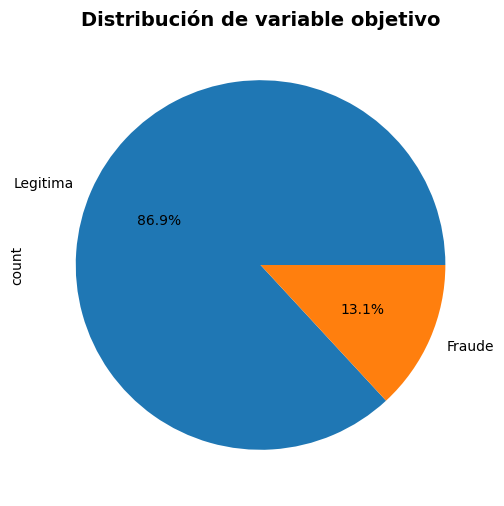

In [ ]:

# Revisa la distribución de la variable objetivo
# En este caso se obtiene un gráfico de torta
data[target].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['Legitima', 'Fraude'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()

## `DecisionTreeClasiffier`

In [ ]:
# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [ ]:
data.columns

Index(['amount', 'hour', 'distance_km', 'is_international',
       'device_risk_score', 'is_fraud'],
      dtype='object')

In [ ]:
features_num = ["amount", "hour", "distance_km", "device_risk_score"]
features_cat = ["is_international"]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough",
    force_int_remainder_cols=False
)

In [ ]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_dtc = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("ciclico", "passthrough"),
    ("preprocesador", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeClassifier())
])

In [ ]:
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=29, stratify=y)

In [ ]:
# Evaluación
metricas_dtc = evaluar(pipeline_modelo_dtc, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc['recall']:.4f}")

Accuracy            : 0.8350
F1 Score:           : 0.4065
ROC AUC Score       : 0.6636
Precision           : 0.3844
Recall              : 0.4313


In [ ]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_dtc.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_dtc.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :1.00000
Score del modelo en test                :0.83500


In [ ]:
pipeline_modelo_dtc

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x7a78315867a0>,
                                     kw_args={'drop': False})),
                ('ciclico', 'passthrough'),
                ('preprocesador',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['amount', 'hour',
                                                   'distance_km',
                                                   'device_risk_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['is_international'])])),
                ('colinealidad', CorrelationFilter()),
                ('modelo', DecisionTreeClassifier())])

In [ ]:
resultados = cross_validate(
    pipeline_modelo_dtc,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=True
)

print(f"{'Accuracy promedio':<20}:{resultados["test_accuracy"].mean():.4f}")
print(f"{'F1 promedio':<20}:{resultados["test_f1"].mean():.4f}")

Accuracy promedio   :0.8376
F1 promedio         :0.3652


In [ ]:
resultados

{'fit_time': array([0.19430017, 0.14232993, 0.15803838, 0.15109873, 0.14647102]),
 'score_time': array([0.05753827, 0.08169675, 0.08333182, 0.06987405, 0.05521441]),
 'test_accuracy': array([0.836875, 0.836875, 0.84    , 0.8325  , 0.841875]),
 'train_accuracy': array([1., 1., 1., 1., 1.]),
 'test_precision': array([0.36923077, 0.36507937, 0.39047619, 0.36320755, 0.38743455]),
 'train_precision': array([1., 1., 1., 1., 1.]),
 'test_recall': array([0.34285714, 0.32857143, 0.39047619, 0.36666667, 0.35238095]),
 'train_recall': array([1., 1., 1., 1., 1.]),
 'test_f1': array([0.35555556, 0.34586466, 0.39047619, 0.36492891, 0.36907731]),
 'train_f1': array([1., 1., 1., 1., 1.])}

In [ ]:
param_grid = {
    "modelo__max_depth": [3, 5, 10],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
    "modelo__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    pipeline_modelo_dtc,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('duplicados',
                                        FunctionTransformer(func=<function tratar_duplicados at 0x7a78315867a0>,
                                                            kw_args={'drop': False})),
                                       ('ciclico', 'passthrough'),
                                       ('preprocesador',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeli...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['is_international'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': [None, 'balanced'],
                         'modelo__max_depth': [3, 5, 10],
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [ ]:
print(f"{'Mejores parámetros':<20}: {grid.best_params_}")
print(f"{'Mejor score':<20}:{grid.best_score_:.4f}")

Mejores parámetros  : {'modelo__class_weight': 'balanced', 'modelo__max_depth': 5, 'modelo__min_samples_leaf': 4, 'modelo__min_samples_split': 2}
Mejor score         :0.4747


In [ ]:
best_model = grid.best_estimator_

In [ ]:
best_model

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x7a78315867a0>,
                                     kw_args={'drop': False})),
                ('ciclico', 'passthrough'),
                ('preprocesador',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('escalado',
                                                                   Stand...)]),
                                                  ['amount', 'hour',
                                                   'distance_km',
                                                   'device_risk_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['is_international'])])),
                ('colinealidad', CorrelationFilter()),
                ('modelo',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=4))])

In [ ]:
# Evaluación
metricas_dtc_mejor = evaluar(best_model, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc_mejor['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc_mejor['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc_mejor['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc_mejor['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc_mejor['recall']:.4f}")

Accuracy            : 0.8090
F1 Score:           : 0.4838
ROC AUC Score       : 0.8329
Precision           : 0.3745
Recall              : 0.6832


In [ ]:
print(f"{'Score del modelo en entrenamiento':<40}:{best_model.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{best_model.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.82888
Score del modelo en test                :0.80900


## `LogisticRegression`

In [ ]:
def transformar_hora_ciclica(X: pd.DataFrame) -> pd.DataFrame:
  """
  Transforma la hora en una variable cíclica

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.

  Retorna
  -------
  DataFrame
    Conjunto de datos con la variable cíclica.
  """
  X = X.copy()
  X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
  X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)
  X = X.drop(columns=["hour"])
  return X

In [ ]:
features_num = ["amount",
                "hour_sin", "hour_cos", # Salen de la transformación cíclica
                "distance_km", "device_risk_score"]
features_cat = ["is_international"]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough",
    force_int_remainder_cols=False
)

# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_lr = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("ciclico", FunctionTransformer(transformar_hora_ciclica)),
    ("preprocesador", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LogisticRegression(max_iter=1000))
])

In [ ]:
param_grid = {"modelo__C": [0.1, 1, 10]}
grid_lr = GridSearchCV(
    pipeline_modelo_lr,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('duplicados',
                                        FunctionTransformer(func=<function tratar_duplicados at 0x7a78315867a0>,
                                                            kw_args={'drop': False})),
                                       ('ciclico',
                                        FunctionTransformer(func=<function transformar_hora_ciclica at 0x7a783108ec00>)),
                                       ('preprocesador',
                                        ColumnTransformer(force_int_remainder...
                                                                          'hour_cos',
                                                                          'distance_km',
                                                                          'device_risk_score']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['is_international'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1, param_grid={'modelo__C': [0.1, 1, 10]}, scoring='f1')

In [ ]:
best_model = grid_lr.best_estimator_

In [ ]:
# Evaluación
metricas_lr_mejor = evaluar(best_model, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_lr_mejor['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_lr_mejor['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr_mejor['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_lr_mejor['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_lr_mejor['recall']:.4f}")

Accuracy            : 0.8950
F1 Score:           : 0.4776
ROC AUC Score       : 0.8511
Precision           : 0.6857
Recall              : 0.3664


In [ ]:
print(f"{'Score del modelo en entrenamiento':<40}:{best_model.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{best_model.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.89150
Score del modelo en test                :0.89500


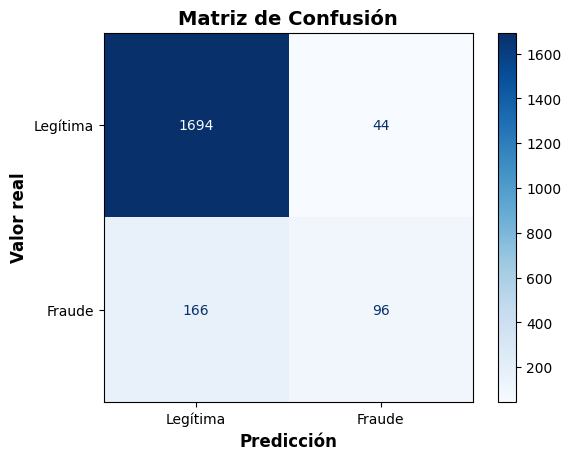

In [ ]:
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legítima", "Fraude"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

In [ ]:
y_prob = best_model.predict_proba(X_test)[:,1]
y_prob[:3]

array([0.66832216, 0.45992862, 0.15950226])

In [ ]:
y_pred[:3]

array([ True, False, False])

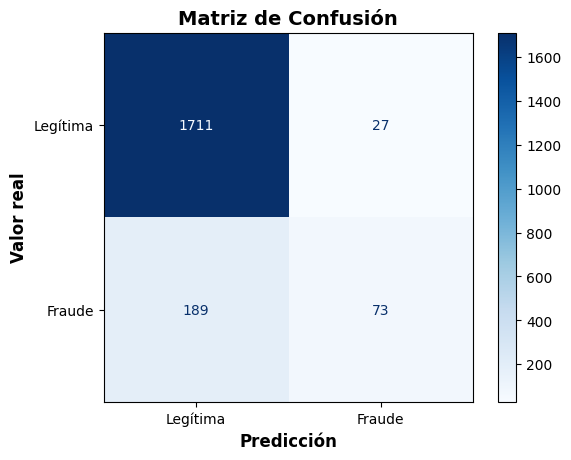

In [ ]:
y_pred = y_prob > 0.6
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legítima", "Fraude"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

# Cierre pedagógico

+ No todos los modelos necesitan el mismo feature engineering
+ Lo que ayuda a uno (Regresión Logística) puede ser irrelevante para otro (Árbol de decisión)